In [2]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as constants
import referenceFrames as rf

In [3]:
sim = Simulation("MechanicalVignetting")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

# One full-frame exposure

sim["ObservingParameters/NumExposures"] = 1
sim["SubField/NumRows"] = 4510
sim["SubField/NumColumns"] = 4510

# Make sure no sources are located in the sub-field

sim["ObservingParameters/DecPointing"] = -sim["ObservingParameters/DecPointing"]

# Enable mechanical vignetting

sim["CCD/IncludeMechanicalVignetting"] = "yes"

In [4]:
pixelSize = sim["CCD/PixelSize"] / 1000.0    # Pixel size [mm]
fovDegrees = sim["CCD/Vignetting/MechanicalVignetting/RadiusFOV"]

In [5]:
# Disable open-shutter smearing

outputWithoutOSS = sim.run(removeOutputFile = True)
imageNoOffsetWithoutOSS = outputWithoutOSS.getImage(0)

# Enable open-shutter smearing

sim["CCD/IncludeOpenShutterSmearing"] = "yes"
outputWithOSS = sim.run(removeOutputFile = True)


2019-11-06 16:11:04 WARNING Simulation: no information about detected stars to write to HDF5
2019-11-06 16:11:04 WARNING Camera: No star positions to write to HDF5 file.


2019-11-06 16:11:06 WARNING Simulation: no information about detected stars to write to HDF5
2019-11-06 16:11:07 WARNING Camera: No star positions to write to HDF5 file.



In [7]:
# Calculate the size of the FOV in pixels

xFP, yFP = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(np.deg2rad(fovDegrees), sim["Camera/FocalLength/ConstantValue"] * 1000, 0)     # Edge of the FOV along the x-axis
radiusPixels, zero = rf.focalPlaneToPixelCoordinates(xFP, yFP, sim["CCD/PixelSize"], 0, 0, 0)     # (size of the FOV, 0)
intersection = math.sqrt(radiusPixels**2 - sim["CCD/NumColumns"]**2)     # Where does the edge of the FOV intersect with the x-axis and the y-axis?

In [9]:
diffImage = outputWithOSS.getImage(0) - outputWithoutOSS.getImage(0)  # Contribution from open-shutter smearing
normalizationFactor = diffImage[0][0]

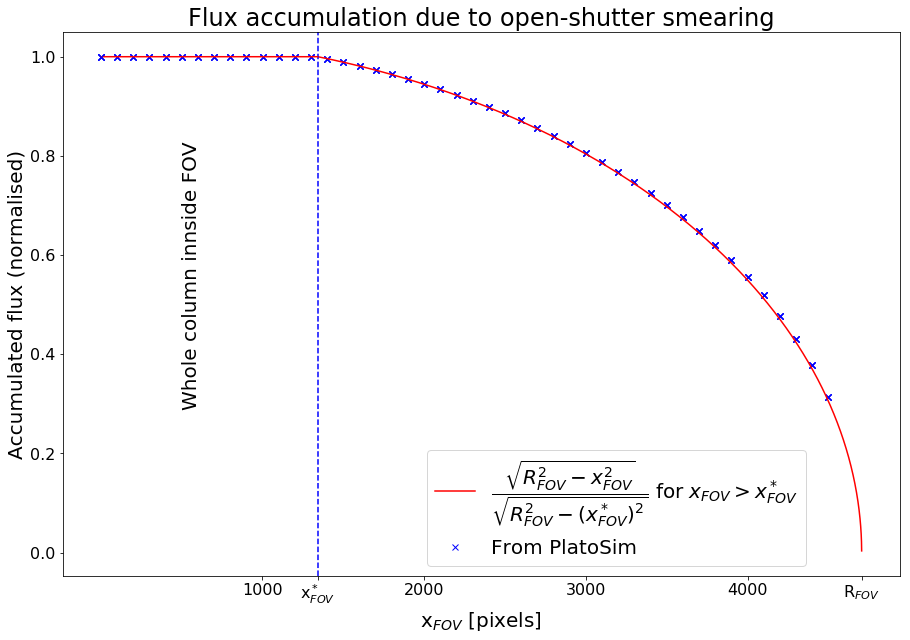

In [10]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

for row in range(0, sim["SubField/NumRows"], 1000):
    
    for column in range(0, sim["SubField/NumColumns"], 100):
        
        try:
            plt.plot([column + 0.5], diffImage[row][column] / normalizationFactor, "bx")
        except:
            pass



######################################
# Not all pixels in column illuminated
######################################

label = "$\dfrac{\sqrt{R_{FOV}^2 - x_{FOV}^2}}{\sqrt{R_{FOV}^2 - (x_{FOV}^*)^2}}$ for $x_{FOV} > x_{FOV}^*$"
r = np.arange(intersection, radiusPixels)
y = np.sqrt(radiusPixels**2 - r**2) / np.sqrt(radiusPixels**2 - intersection**2)
plt.plot(r, y, "r", label = label)



#######################################
# Intersection with the edge of the FOV
#######################################

ax.axvline(x = intersection, color = "b", linestyle = "--")



################################
# Completely illumimated columns
################################

plt.plot(np.arange(math.floor(intersection)), np.ones(math.floor(intersection)), "r")



########
# Layout
########

plt.text(500, 0.8, "Whole column innside FOV", fontsize = 20, rotation = 90)

plt.title("Flux accumulation due to open-shutter smearing", fontsize = 24)
plt.xlabel("x$_{FOV}$ [pixels]", fontsize = 20)
plt.ylabel("Accumulated flux (normalised)", fontsize = 20)

x = [intersection, radiusPixels, 1000, 2000, 3000, 4000]
labels = ["x$_{FOV}^*$", "R$_{FOV}$", "1000", "2000", "3000", "4000"]

plt.plot([0], [1], "bx", label = "From PlatoSim")

plt.xticks(x, labels, fontsize = 16)

for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

plt.legend(loc='lower right',  bbox_to_anchor=(0.9, 0.0), fontsize = 20)

plt.show()